# 🩺 Exploratory Data Analysis & Data Cleaning
## Pima Indians Diabetes Dataset
**Objective**: End-to-end data exploration, physiological zero-missingness resolution, outlier analysis, clinical feature engineering, and preprocessing for machine learning readiness.

---

### Dataset Summary
* **Source**: National Institute of Diabetes and Digestive and Kidney Diseases (NIDDK)
* **Sample Population**: Female patients of Pima Indian heritage (at least 21 years old)
* **Observations**: 768 instances
* **Target**: `Outcome` (0 = Non-Diabetic, 1 = Diabetic)


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Add project root to sys.path
sys.path.append(os.path.abspath('..'))

from src.data_loader import load_raw_data, ZERO_AS_MISSING_COLS, FEATURE_METADATA
from src.cleaner import mark_hidden_missing_values, impute_missing_values, handle_outliers, engineer_features, scale_features
from src.eda_analyzer import generate_summary_statistics, compute_missingness_report, compute_bivariate_stats, detect_outliers_iqr

# Plotting configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
%matplotlib inline


## 1. Raw Dataset Ingestion & Initial Inspection
Let's load the raw dataset and inspect its structure, data types, and initial summary statistics.


In [2]:
df_raw = load_raw_data('../data/raw/diabetes.csv')
print(f"Dataset Dimensions: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns")
df_raw.head(10)


Dataset Dimensions: 768 rows, 9 columns


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


In [3]:
df_raw.info()
df_raw.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Uncovering Hidden Missing Values (Physiological Zeros)

In standard datasets, missing values are typically represented as `NaN` or `null`. In this dataset:
* `Pregnancies = 0` is biologically valid (a woman has never been pregnant).
* `Outcome = 0` is valid (negative class label).
* However, **`Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, and `BMI` CANNOT be 0 in living humans**.

Let's quantify the extent of these hidden missing values:


In [4]:
missing_report = compute_missingness_report(df_raw)
missing_report


,Total_Rows,Zero_Count,Is_Physiologically_Missing,True_Missing_Count,Missing_Percentage
Feature,,,,,
Pregnancies,768,111,False,0,0.00
Glucose,768,5,True,5,0.65
BloodPressure,768,35,True,35,4.56
SkinThickness,768,227,True,227,29.56
Insulin,768,374,True,374,48.70
BMI,768,11,True,11,1.43
DiabetesPedigreeFunction,768,0,False,0,0.00
Age,768,0,False,0,0.00


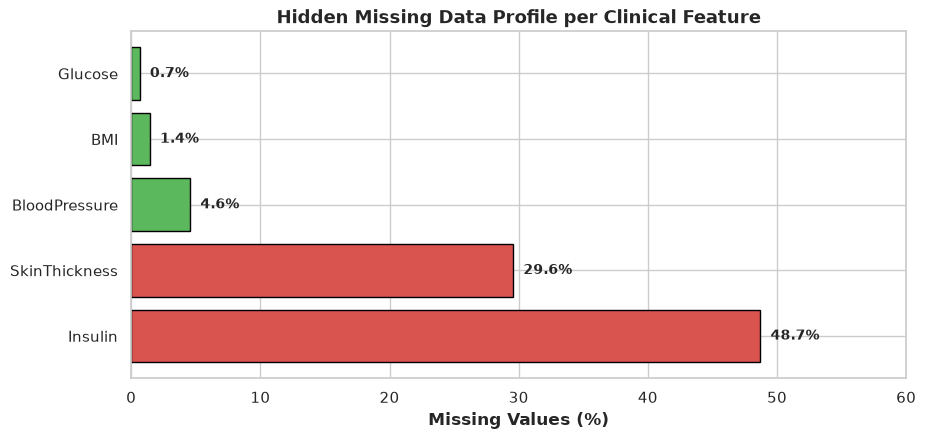

In [5]:
df_nan = mark_hidden_missing_values(df_raw)

# Bar chart of missingness percentage
fig, ax = plt.subplots(figsize=(10, 4.5))
missing_pcts = (df_nan[ZERO_AS_MISSING_COLS].isna().mean() * 100).sort_values(ascending=False)
colors = ['#d9534f' if p > 20 else '#f0ad4e' if p > 5 else '#5cb85c' for p in missing_pcts]

bars = ax.barh(missing_pcts.index, missing_pcts.values, color=colors, edgecolor='black')
ax.set_xlabel('Missing Values (%)', fontweight='bold')
ax.set_title('Hidden Missing Data Profile per Clinical Feature', fontsize=13, fontweight='bold')
ax.set_xlim(0, 60)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.8, bar.get_y() + bar.get_height()/2, f'{w:.1f}%', va='center', fontweight='bold')
plt.show()


## 3. Target Variable Analysis: Class Imbalance
Let's inspect the baseline prevalence of diabetes in this cohort.


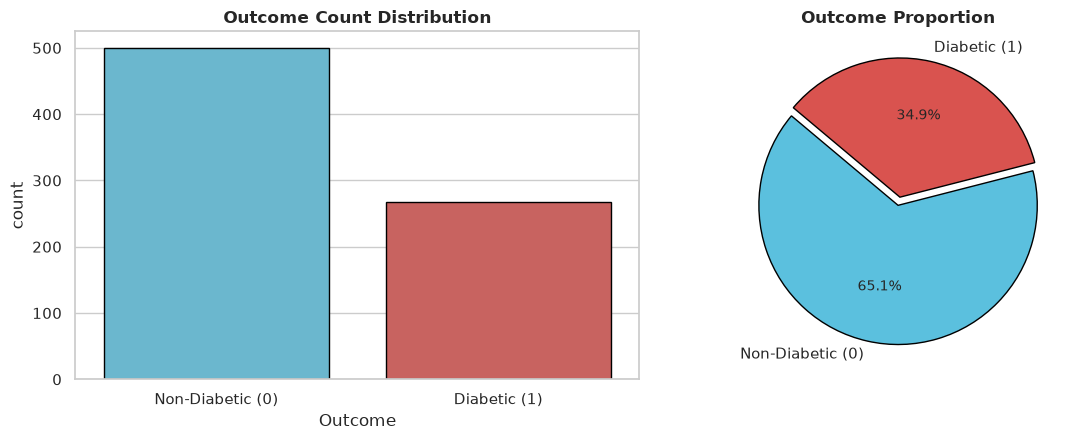

Cohort Balance: 500 non-diabetic (65.1%) vs 268 diabetic (34.9%)


In [6]:
counts = df_raw['Outcome'].value_counts()
pcts = df_raw['Outcome'].value_counts(normalize=True) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(data=df_raw, x='Outcome', hue='Outcome', palette=['#5bc0de', '#d9534f'], legend=False, ax=ax1, edgecolor='black')
ax1.set_xticks([0, 1])
ax1.set_xticklabels(['Non-Diabetic (0)', 'Diabetic (1)'])
ax1.set_title('Outcome Count Distribution', fontweight='bold')

ax2.pie(counts, labels=['Non-Diabetic (0)', 'Diabetic (1)'], autopct='%1.1f%%', colors=['#5bc0de', '#d9534f'],
        explode=[0, 0.06], startangle=140, wedgeprops=dict(edgecolor='black'))
ax2.set_title('Outcome Proportion', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Cohort Balance: {counts[0]} non-diabetic ({pcts[0]:.1f}%) vs {counts[1]} diabetic ({pcts[1]:.1f}%)")


## 4. Univariate Distributions & Skewness Analysis
Let's analyze feature central tendencies, variance, skewness, and kurtosis.


In [7]:
summary_stats = generate_summary_statistics(df_nan)
summary_stats


,Count,Mean,Std,Min,25%,Median (50%),75%,Max,Skewness,Kurtosis,Zero_Count,Zero_Pct(%),NaN_Count,NaN_Pct(%)
Feature,,,,,,,,,,,,,,
Pregnancies,768,3.845,3.370,0.000,1.000,3.000,6.000,17.00,0.900,0.150,111,14.45,0,0.00
Glucose,763,121.687,30.536,44.000,99.000,117.000,141.000,199.00,0.530,-0.283,0,0.00,5,0.65
BloodPressure,733,72.405,12.382,24.000,64.000,72.000,80.000,122.00,0.134,0.897,0,0.00,35,4.56
SkinThickness,541,29.153,10.477,7.000,22.000,29.000,36.000,99.00,0.689,2.897,0,0.00,227,29.56
Insulin,394,155.548,118.776,14.000,76.250,125.000,190.000,846.00,2.158,6.275,0,0.00,374,48.70
BMI,757,32.457,6.925,18.200,27.500,32.300,36.600,67.10,0.593,0.850,0,0.00,11,1.43
DiabetesPedigreeFunction,768,0.472,0.331,0.078,0.244,0.372,0.626,2.42,1.916,5.551,0,0.00,0,0.00
Age,768,33.241,11.760,21.000,24.000,29.000,41.000,81.00,1.127,0.631,0,0.00,0,0.00
Outcome,768,0.349,0.477,0.000,0.000,0.000,1.000,1.00,0.634,-1.598,500,65.10,0,0.00


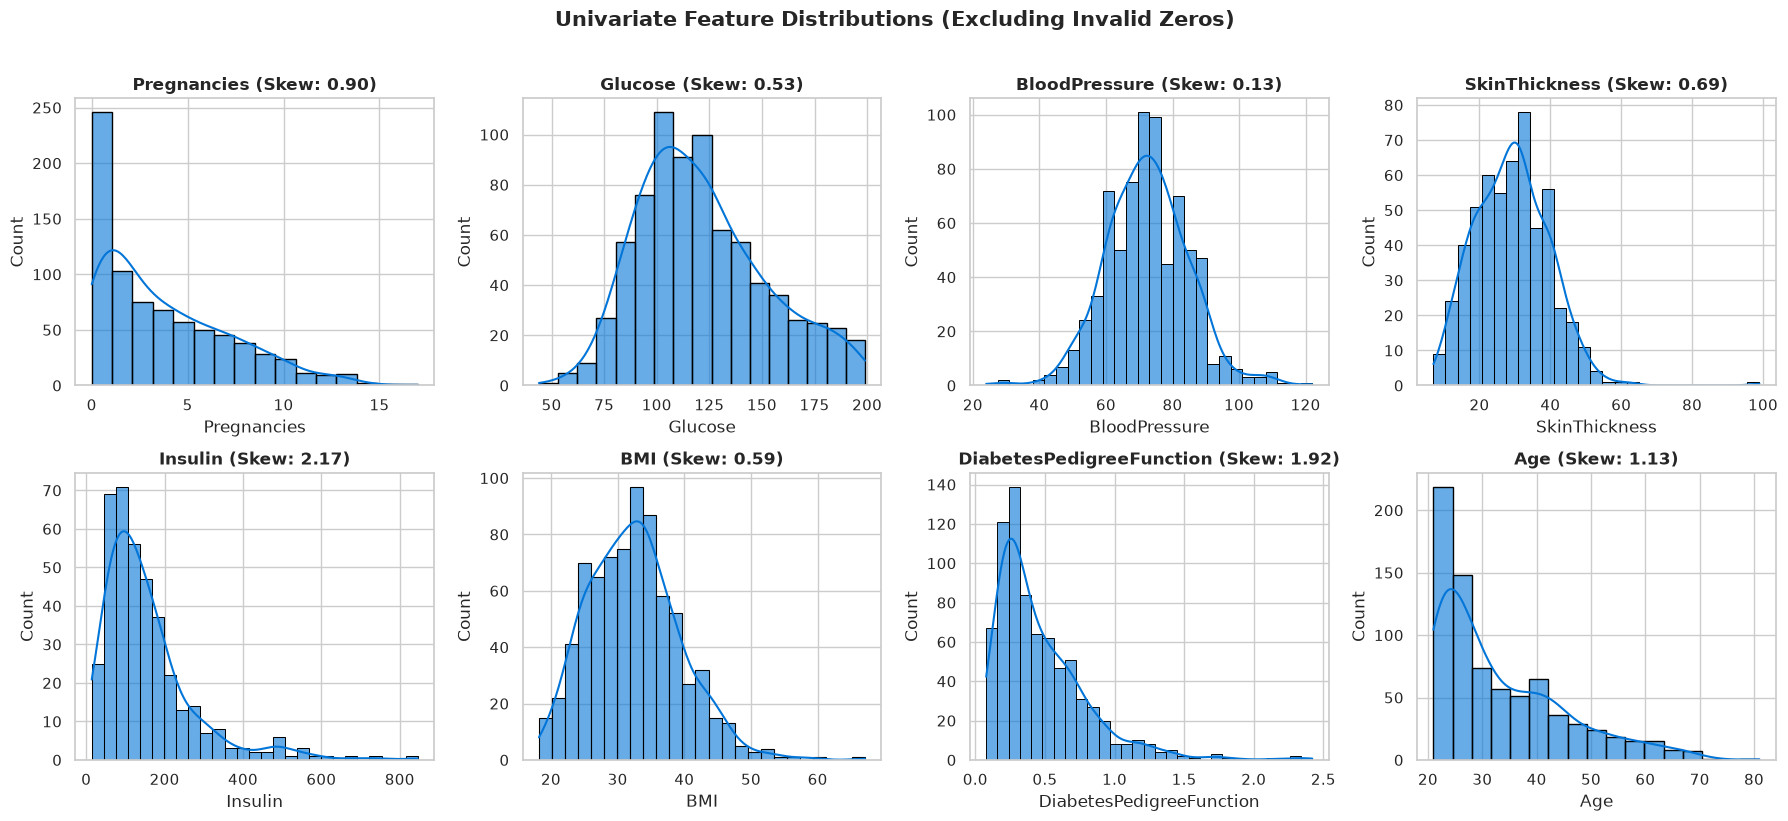

In [8]:
features = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(df_nan[col], kde=True, ax=axes[i], color='#0275d8', edgecolor='black', alpha=0.6)
    skew = df_nan[col].skew()
    axes[i].set_title(f"{col} (Skew: {skew:.2f})", fontweight='bold')
    
plt.suptitle("Univariate Feature Distributions (Excluding Invalid Zeros)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 5. Bivariate Exploration & Statistical Hypothesis Testing

We perform **Mann-Whitney U non-parametric two-sample tests** to determine whether distributions significantly differ between diabetic and non-diabetic cohorts.


In [9]:
bivariate_results = compute_bivariate_stats(df_nan)
bivariate_results


,NonDiabetic_Mean,NonDiabetic_Median,NonDiabetic_IQR,Diabetic_Mean,Diabetic_Median,Diabetic_IQR,MannWhitney_U_Stat,p_value,Statistically_Significant (p<0.05)
Feature,,,,,,,,,
Pregnancies,3.30,2.00,4.00,4.87,4.00,6.25,50985.0,3.75e-08,True
Glucose,110.64,107.00,32.00,142.32,140.00,48.00,27393.5,1.31e-40,True
BloodPressure,70.88,70.00,16.00,75.32,74.50,16.00,47566.5,1.63e-06,True
SkinThickness,27.24,27.00,14.00,33.00,32.00,12.00,21930.0,6.96e-10,True
Insulin,130.29,102.50,95.25,206.85,169.50,111.75,9210.5,7.48e-14,True
BMI,30.86,30.10,9.70,35.41,34.30,8.02,40875.0,1.82e-17,True
DiabetesPedigreeFunction,0.43,0.34,0.33,0.55,0.45,0.47,52769.0,1.20e-06,True
Age,31.19,27.00,14.00,37.07,36.00,16.00,41950.0,1.14e-17,True


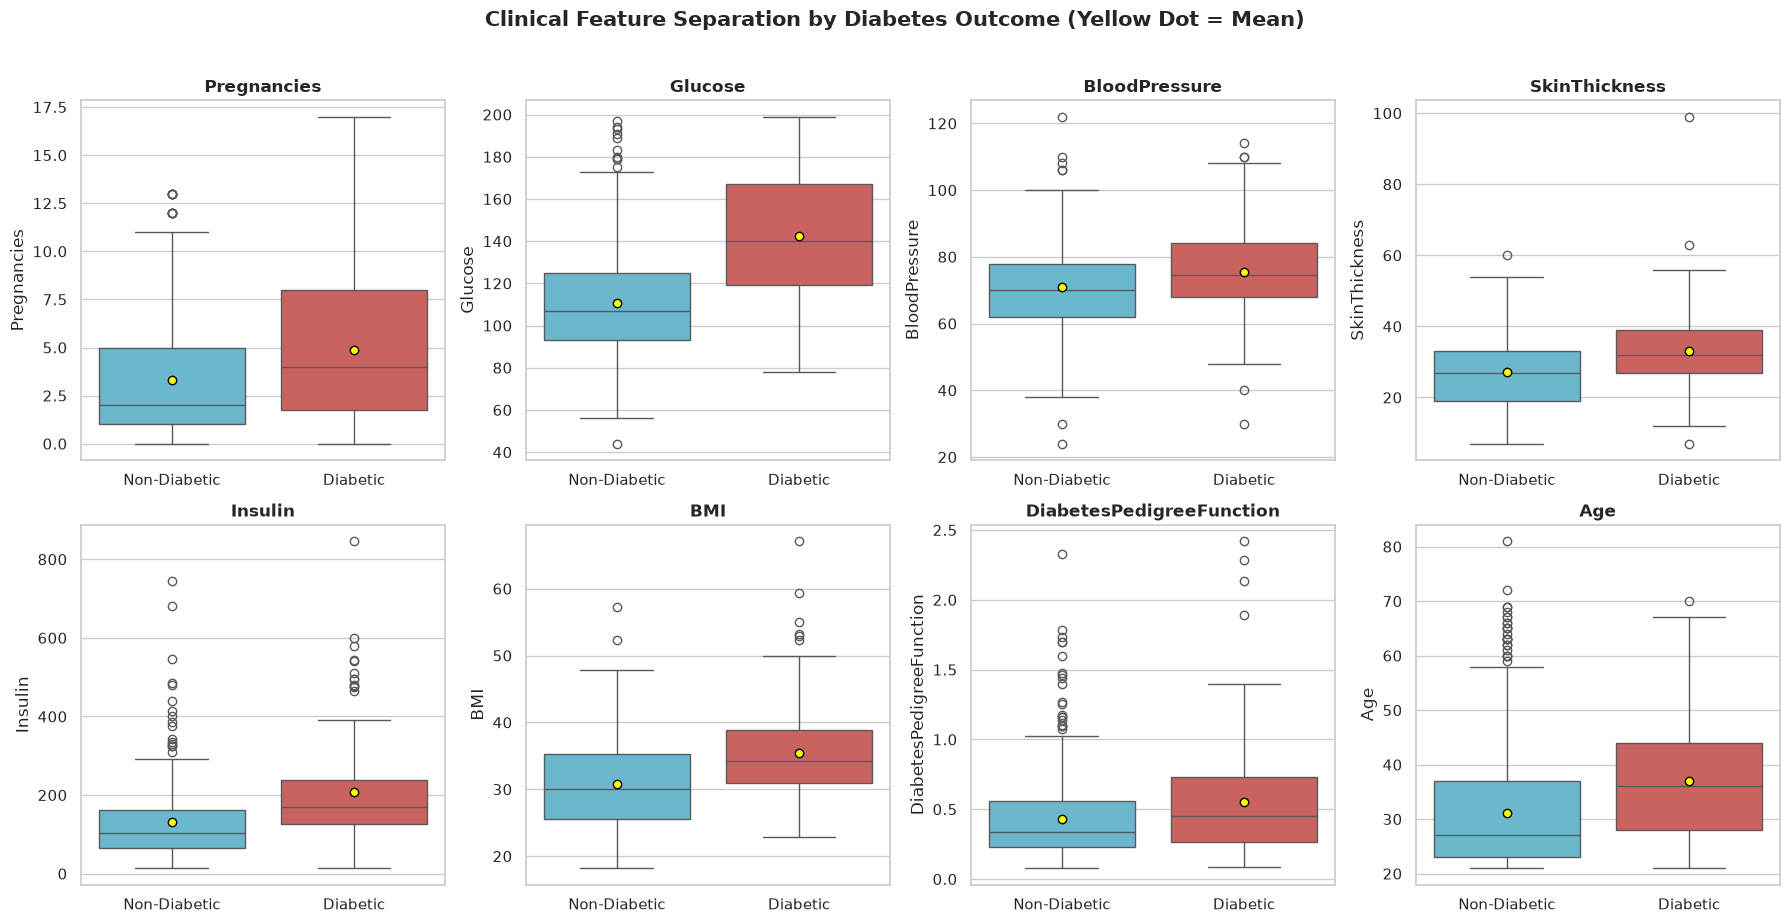

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(
        x='Outcome',
        y=col,
        hue='Outcome',
        data=df_nan,
        ax=axes[i],
        palette=['#5bc0de', '#d9534f'],
        legend=False,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "yellow", "markeredgecolor": "black"}
    )
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Non-Diabetic', 'Diabetic'])
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle("Clinical Feature Separation by Diabetes Outcome (Yellow Dot = Mean)", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## 6. Correlation Matrices & Multicollinearity
Let's analyze linear (Pearson) and monotonic rank (Spearman) relationships between predictors and target.


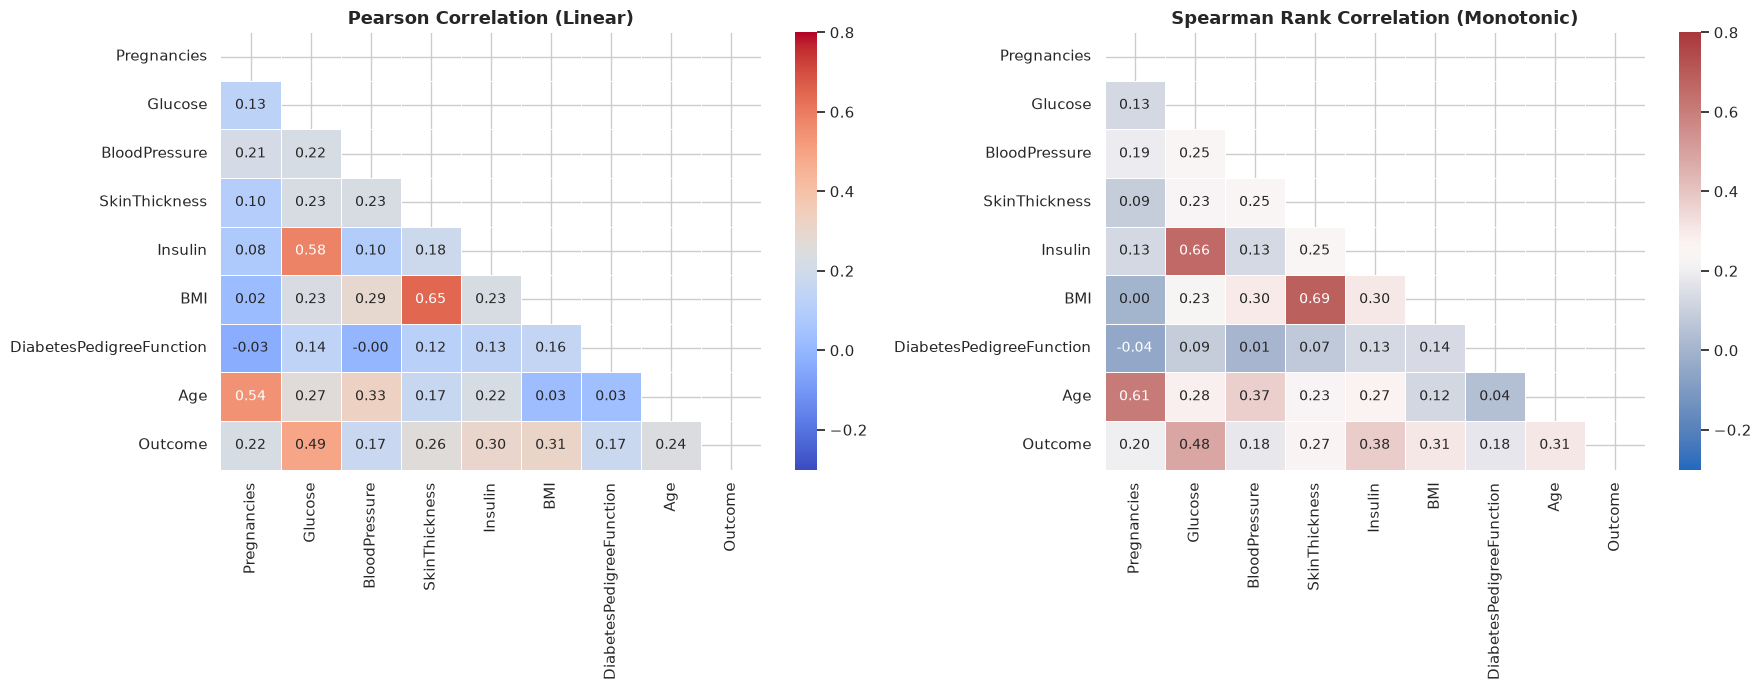

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

corr_pearson = df_nan.corr(method='pearson')
corr_spearman = df_nan.corr(method='spearman')
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

sns.heatmap(corr_pearson, annot=True, fmt='.2f', cmap='coolwarm', vmin=-0.3, vmax=0.8, mask=mask, ax=ax1, linewidths=0.5)
ax1.set_title('Pearson Correlation (Linear)', fontsize=13, fontweight='bold')

sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='vlag', vmin=-0.3, vmax=0.8, mask=mask, ax=ax2, linewidths=0.5)
ax2.set_title('Spearman Rank Correlation (Monotonic)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


## 7. Outlier Detection & IQR Fencing
Let's compute IQR lower and upper fences ($Q25 - 1.5 	imes IQR$ and $Q75 + 1.5 	imes IQR$) to identify extreme values.


In [12]:
outliers_table = detect_outliers_iqr(df_nan)
outliers_table


,Q25,Q75,IQR,Lower_Fence,Upper_Fence,Outlier_Count,Outlier_Pct(%),Min_Value,Max_Value
Feature,,,,,,,,,
Pregnancies,1.00,6.00,5.00,-6.50,13.50,4,0.52,0.00,17.00
Glucose,99.00,141.00,42.00,36.00,204.00,0,0.00,44.00,199.00
BloodPressure,64.00,80.00,16.00,40.00,104.00,14,1.91,24.00,122.00
SkinThickness,22.00,36.00,14.00,1.00,57.00,3,0.55,7.00,99.00
Insulin,76.25,190.00,113.75,-94.38,360.62,24,6.09,14.00,846.00
BMI,27.50,36.60,9.10,13.85,50.25,8,1.06,18.20,67.10
DiabetesPedigreeFunction,0.24,0.63,0.38,-0.33,1.20,29,3.78,0.08,2.42
Age,24.00,41.00,17.00,-1.50,66.50,9,1.17,21.00,81.00


## 8. Data Cleaning: Imputation & Outlier Handling

### Imputation Strategies:
1. **Outcome-Conditioned Group Median**: Imputes the median of each class (`Outcome = 0` vs `Outcome = 1`) to preserve group separation.
2. **KNN Imputation**: Uses multi-feature proximity to infer missing clinical values.
3. **Outlier Treatment**: Winsorization at 1st and 99th percentiles preserves observation counts while protecting models from extreme leverage points.


In [13]:
# 1. Impute using Group Medians
df_imputed = impute_missing_values(df_nan, strategy='median_by_outcome')

# 2. Outlier Capping (Winsorization)
df_cleaned = handle_outliers(df_imputed, method='winsorize', lower_quantile=0.01, upper_quantile=0.99)

print("Missing values in cleaned dataset:", df_cleaned.isna().sum().to_dict())
df_cleaned.describe().T


Missing values in cleaned dataset: {'Pregnancies': 0, 'Glucose': 0, 'BloodPressure': 0, 'SkinThickness': 0, 'Insulin': 0, 'BMI': 0, 'DiabetesPedigreeFunction': 0, 'Age': 0, 'Outcome': 0}


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.00000,1.00000,3.0000,6.00000,17.00000
Glucose,768.0,121.759583,30.245445,67.67000,99.75000,117.0000,140.25000,196.00000
BloodPressure,768.0,72.412760,11.711780,44.00000,64.00000,72.0000,80.00000,106.00000
SkinThickness,768.0,28.999531,8.403454,10.00000,25.00000,28.0000,32.00000,51.33000
Insulin,768.0,140.618385,82.254001,24.34000,102.50000,102.5000,169.50000,519.90000
BMI,768.0,32.385510,6.672210,19.50000,27.50000,32.0500,36.60000,50.75900
DiabetesPedigreeFunction,768.0,0.468461,0.314849,0.09468,0.24375,0.3725,0.62625,1.69833
Age,768.0,33.205729,11.645318,21.00000,24.00000,29.0000,41.00000,67.00000
Outcome,768.0,0.348958,0.476951,0.00000,0.00000,0.0000,1.00000,1.00000


## 9. Domain-Specific Feature Engineering

We create clinically grounded predictors:
1. **`BMI_Category`**: WHO standard categorizations (`Underweight`, `Normal`, `Overweight`, `Obese`).
2. **`Glucose_Risk`**: OGTT diagnostic categories (`Normal`, `Prediabetes`, `Diabetes_Range`).
3. **`HOMA_IR_Proxy`**: Insulin resistance proxy index $(\text{Glucose} \times \text{Insulin}) / 405$.
4. **`Pregnancy_Rate`**: $\text{Pregnancies} / \text{Age}$.
5. **`Metabolic_Risk_Score`**: Count of co-occurring metabolic syndrome risk factors.


In [14]:
df_engineered = engineer_features(df_cleaned)
print(f"Total features after engineering: {df_engineered.shape[1]}")
df_engineered.head(10)


Total features after engineering: 15


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Category,Glucose_Risk,Age_Group,Pregnancy_Rate,HOMA_IR_Proxy,Metabolic_Risk_Score
0,6,148.0,72.0,35.0,169.5,33.6,0.62700,50,1,Obese,Prediabetes,Senior,0.120000,61.940741,3
1,1,85.0,66.0,29.0,102.5,26.6,0.35100,31,0,Overweight,Normal,Middle,0.032258,21.512346,0
2,8,183.0,64.0,32.0,169.5,23.3,0.67200,32,1,Normal,Prediabetes,Middle,0.250000,76.588889,1
3,1,89.0,66.0,23.0,94.0,28.1,0.16700,21,0,Overweight,Normal,Young,0.047619,20.656790,0
4,0,137.0,44.0,35.0,168.0,43.1,1.69833,33,1,Obese,Normal,Middle,0.000000,56.829630,1
5,5,116.0,74.0,27.0,102.5,25.6,0.20100,30,0,Overweight,Normal,Middle,0.166667,29.358025,0
6,3,78.0,50.0,32.0,88.0,31.0,0.24800,26,1,Obese,Normal,Young,0.115385,16.948148,1
7,10,115.0,70.0,27.0,102.5,35.3,0.13400,29,0,Obese,Normal,Young,0.344828,29.104938,1
8,2,196.0,70.0,45.0,519.9,30.5,0.15800,53,1,Obese,Prediabetes,Senior,0.037736,251.605926,3
9,8,125.0,96.0,32.0,169.5,34.3,0.23200,54,1,Obese,Normal,Senior,0.148148,52.314815,3


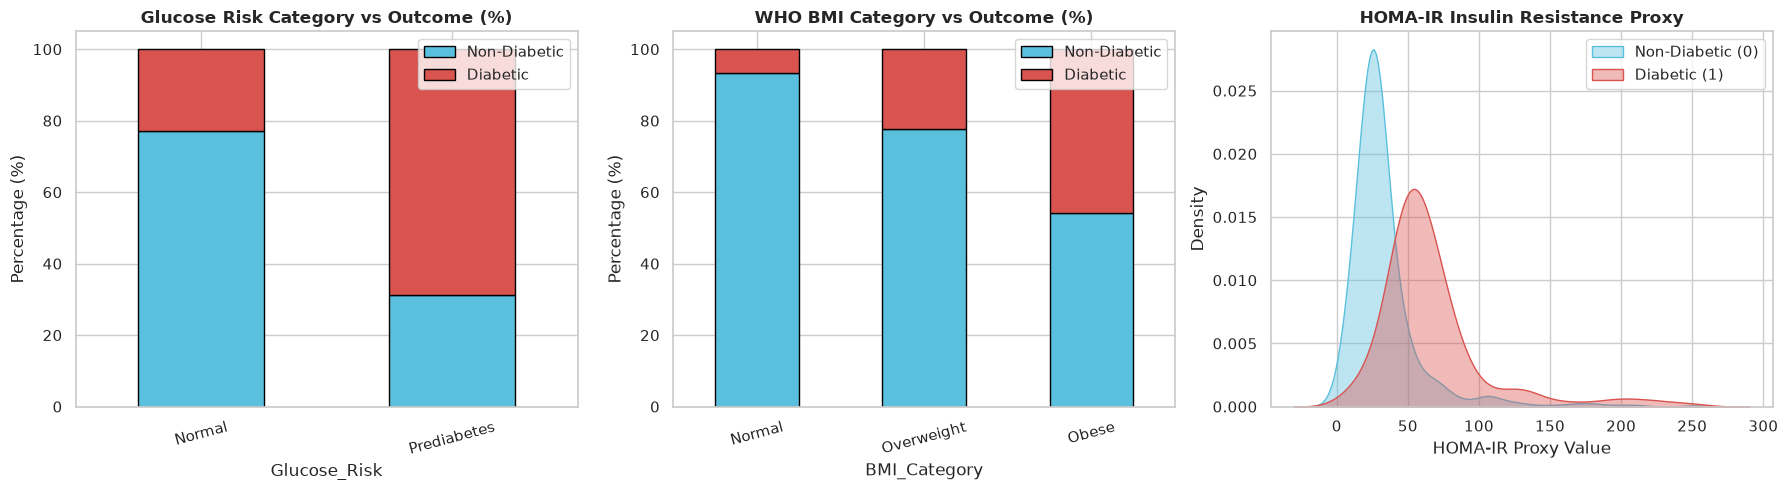

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Glucose Risk
pd.crosstab(df_engineered['Glucose_Risk'], df_engineered['Outcome'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, color=['#5bc0de', '#d9534f'], ax=axes[0], edgecolor='black'
)
axes[0].set_title('Glucose Risk Category vs Outcome (%)', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend(['Non-Diabetic', 'Diabetic'])

# 2. BMI Category
pd.crosstab(df_engineered['BMI_Category'], df_engineered['Outcome'], normalize='index').mul(100).plot(
    kind='bar', stacked=True, color=['#5bc0de', '#d9534f'], ax=axes[1], edgecolor='black'
)
axes[1].set_title('WHO BMI Category vs Outcome (%)', fontweight='bold')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(['Non-Diabetic', 'Diabetic'])

# 3. HOMA-IR Proxy
sns.kdeplot(data=df_engineered[df_engineered['Outcome']==0]['HOMA_IR_Proxy'], ax=axes[2], label='Non-Diabetic (0)', color='#5bc0de', fill=True, alpha=0.4)
sns.kdeplot(data=df_engineered[df_engineered['Outcome']==1]['HOMA_IR_Proxy'], ax=axes[2], label='Diabetic (1)', color='#d9534f', fill=True, alpha=0.4)
axes[2].set_title('HOMA-IR Insulin Resistance Proxy', fontweight='bold')
axes[2].set_xlabel('HOMA-IR Proxy Value')
axes[2].legend()

plt.tight_layout()
plt.show()


## 10. Feature Scaling & Dataset Export
We provide scaled feature matrices using `RobustScaler` (dampening residual skewness) and export processed datasets.


In [16]:
# Robust Scaling for modeling
df_scaled, scaler = scale_features(df_cleaned, scaler_type='robust')

# Save outputs
os.makedirs('../data/processed', exist_ok=True)
df_cleaned.to_csv('../data/processed/diabetes_cleaned.csv', index=False)
df_engineered.to_csv('../data/processed/diabetes_engineered.csv', index=False)

print("✅ Data successfully saved:")
print(f" - Cleaned Dataset: data/processed/diabetes_cleaned.csv (Shape: {df_cleaned.shape})")
print(f" - Engineered Dataset: data/processed/diabetes_engineered.csv (Shape: {df_engineered.shape})")


✅ Data successfully saved:
 - Cleaned Dataset: data/processed/diabetes_cleaned.csv (Shape: (768, 9))
 - Engineered Dataset: data/processed/diabetes_engineered.csv (Shape: (768, 15))
